# 7.01 Extracting top 100 books from Gutenberg

In [176]:
# Import Necessary libraries including regex an BeautifulSoup
import pandas as pd
from bs4 import BeautifulSoup as bs
import requests
import regex
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# Read HTML from URL https://www.gutenberg.org

url = 'https://www.gutenberg.org/browse/scores/top'

response = requests.get(url)

In [117]:
# write small function to check status
def status_chk(r):
    if r.status_code == 200:
        return 1
    else:
        return -1

def get_encoding(r):
    return (r.encoding)


def decode_webpage(r,encoding):

    return (r.content.decode(encoding))

In [118]:
status = status_chk(response)
if status == 1 :
         print("Connection Succesful to the URL")
         webpage = decode_webpage(response, get_encoding(response))
         print(webpage)
    
else:
        print("Sorry, webpage could not be reached")


Connection Succesful to the URL
<!DOCTYPE html>
<html class="client-nojs" lang="en" dir="ltr">
<head>
 <meta charset="UTF-8"/>

<title>Top 100 | Project Gutenberg</title>
 <link rel="stylesheet" href="/gutenberg/style.css?v=1.1">
 <link rel="stylesheet" href="/gutenberg/collapsible.css?1.1">
 <link rel="stylesheet" href="/gutenberg/new_nav.css?v=1.321231">
<link rel="stylesheet" href="/gutenberg/pg-desktop-one.css">
 <meta name="viewport" content="width=device-width, initial-scale=1">
 <meta name="keywords" content="books, ebooks, free, kindle, android, iphone, ipad"/>
 <meta name="google-site-verification" content="wucOEvSnj5kP3Ts_36OfP64laakK-1mVTg-ptrGC9io"/>
 <meta name="alexaVerifyID" content="4WNaCljsE-A82vP_ih2H_UqXZvM"/>
 <link rel="copyright" href="https://www.gnu.org/copyleft/fdl.html"/>
 <link rel="icon" type="image/png" href="/gutenberg/favicon.ico" sizes="16x16" />
 <meta property="og:title"        content="Project Gutenberg" />
 <meta property="og:type"         content="w

In [119]:
#  Pass the decoded webpage to BeautifulSoup for HTML parsing
bsp = bs(webpage,'html.parser')
bsp 

<!DOCTYPE html>

<html class="client-nojs" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>Top 100 | Project Gutenberg</title>
<link href="/gutenberg/style.css?v=1.1" rel="stylesheet"/>
<link href="/gutenberg/collapsible.css?1.1" rel="stylesheet"/>
<link href="/gutenberg/new_nav.css?v=1.321231" rel="stylesheet"/>
<link href="/gutenberg/pg-desktop-one.css" rel="stylesheet"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="books, ebooks, free, kindle, android, iphone, ipad" name="keywords">
<meta content="wucOEvSnj5kP3Ts_36OfP64laakK-1mVTg-ptrGC9io" name="google-site-verification"/>
<meta content="4WNaCljsE-A82vP_ih2H_UqXZvM" name="alexaVerifyID"/>
<link href="https://www.gnu.org/copyleft/fdl.html" rel="copyright">
<link href="/gutenberg/favicon.ico" rel="icon" sizes="16x16" type="image/png">
<meta content="Project Gutenberg" property="og:title"/>
<meta content="website" property="og:type"/>
<meta content="https://www.gutenberg.org/" proper

In [120]:
# Find all the href tags and save them in a list, check the list and print the first 30 tags

# Empty list 
list_tags = []

# Find all the href tags and save them in list.

for tag in bsp.find_all('a'):
    list_tags.append(tag.get('href'))

list_tags[20:40]

['/help/faq.html',
 '/policy/',
 '/help/public_domain_ebook_submission.html',
 '/help/submitting_your_own_work.html',
 '/help/mobile.html',
 '/attic/',
 '/donate/',
 '/donate/',
 'pretty-pictures',
 '#books-last1',
 '#authors-last1',
 '#books-last7',
 '#authors-last7',
 '#books-last30',
 '#authors-last30',
 '/ebooks/84',
 '/ebooks/2701',
 '/ebooks/8525',
 '/ebooks/1342',
 '/ebooks/1513']

In [121]:
# use regular expression to find the numeric digits in these tags. these are the file numbers for top 100 books

# Create empty list
list_numbers = []

# Loop through the range 35 to 136 and find the numeric digits using regex
for tag in range(35,136):
    if regex.search(r'\d+', list_tags[tag]):
        list_numbers.append(regex.search(r'\d+', list_tags[tag]).group(0))

# Print the first 30 numbers
print(list_numbers[:30])

['84', '2701', '8525', '1342', '1513', '11', '1023', '64317', '145', '2542', '37106', '100', '844', '2641', '174', '67979', '16389', '43', '2554', '26184', '394', '6761', '345', '2160', '6593', '1259', '4085', '98', '5197', '5200']


In [122]:
# print first 2000 characters of beautiful soup text object

bsp.text[60:2000]

"enu▾\n\n\n\nAbout\n          ▾\n\n▾\n\n\nAbout Project Gutenberg\nCollection Development\nContact Us\nHistory & Philosophy\nPermissions & License\nPrivacy Policy\nTerms of Use\n\n\n\nSearch and Browse\n      \t  ▾\n\n▾\n\n\nBook Search\nMain Categories\nBookshelves\nFrequently Downloaded\nOffline Catalogs\n\n\n\nHelp\n          ▾\n\n▾\n\n\nAll help topics →\nCopyright How-To\nErrata, Fixes and Bug Reports\nFile Formats\nFrequently Asked Questions\nPolicies →\nPublic Domain eBook Submission\nSubmitting Your Own Work\nTablets, Phones and eReaders\nThe Attic →\n\n\nDonate\n\n\n\n\n\n\n\n\n\n\nWays to donate\n\n\n\n\n\n\n\nTo determine the ranking we count the times each file gets downloaded.\nBoth HTTP and FTP transfers are counted.\nOnly transfers from ibiblio.org are counted as we have no access to our mirrors log files.\nMultiple downloads from the same IP address on the same day count as one download.\nIP addresses that download more than 100 files a day are considered\nrobots and ar

In [123]:
# from the text object in bsp and find the index for "top 100 ebooks yesterday" using splitlines method
# and save it in first_index
first_index = bsp.text.splitlines().index("Top 100 EBooks yesterday") 


In [124]:
# search the extracted text ( using regular expression) from the soup object to find the 
# names of the top 100 ebooks ( yesterdays ranking)

# Create empty list
yest_names = []

# Loop from 1 to 100  and add the strings of the next100 lines to the list
for i in range(1,101):
    yest_names.append(bsp.text.splitlines()[first_index + i])
# Print the first 30 names   
print(yest_names[:30])

['', 'Frankenstein; Or, The Modern Prometheus by Mary Wollstonecraft Shelley (4704)', 'Moby Dick; Or, The Whale by Herman Melville (3549)', "Eve's Diary, Complete by Mark Twain (2093)", 'Pride and Prejudice by Jane Austen (2081)', 'Romeo and Juliet by William Shakespeare (1943)', "Alice's Adventures in Wonderland by Lewis Carroll (1865)", 'Bleak House by Charles Dickens (1852)', 'The Great Gatsby by F. Scott  Fitzgerald (1651)', 'Middlemarch by George Eliot (1469)', "A Doll's House : a play by Henrik Ibsen (1448)", 'Little Women; Or, Meg, Jo, Beth, and Amy by Louisa May Alcott (1436)', 'The Complete Works of William Shakespeare by William Shakespeare (1417)', 'The Importance of Being Earnest: A Trivial Comedy for Serious People by Oscar Wilde (1407)', 'A Room with a View by E. M.  Forster (1401)', 'The Picture of Dorian Gray by Oscar Wilde (1328)', 'The Blue Castle: a novel by L. M.  Montgomery (1281)', 'The Enchanted April by Elizabeth Von Arnim (1258)', 'The Strange Case of Dr. Jekyl

In [125]:
#  Use a regular expression to extract only text from the names strongs and append it to an empty list list. Use match and span to 
# find the indices and use them.

# Create empty list
yest_final_titles   = []

# Loop through the range 0 to 100 and extract text from the name strings using regex, match & span
for i in range(0, 100):
    index1, index2 = regex.match(r'^[a-zA-Z ]*', yest_names[i]).span()
    yest_final_titles.append(yest_names[i][index1:index2])



In [126]:
#print o/p

for i in yest_final_titles:
    print(i)


Frankenstein
Moby Dick
Eve
Pride and Prejudice by Jane Austen 
Romeo and Juliet by William Shakespeare 
Alice
Bleak House by Charles Dickens 
The Great Gatsby by F
Middlemarch by George Eliot 
A Doll
Little Women
The Complete Works of William Shakespeare by William Shakespeare 
The Importance of Being Earnest
A Room with a View by E
The Picture of Dorian Gray by Oscar Wilde 
The Blue Castle
The Enchanted April by Elizabeth Von Arnim 
The Strange Case of Dr
Crime and Punishment by Fyodor Dostoyevsky 
Simple Sabotage Field Manual by United States
Cranford by Elizabeth Cleghorn Gaskell 
The Adventures of Ferdinand Count Fathom 
Dracula by Bram Stoker 
The Expedition of Humphry Clinker by T
History of Tom Jones
Twenty years after by Alexandre Dumas and Auguste Maquet 
The Adventures of Roderick Random by T
A Tale of Two Cities by Charles Dickens 
My Life 
Metamorphosis by Franz Kafka 
The art of writing and speaking the English language 
Great Expectations by Charles Dickens 
Thus Spake Z

# 7.02 Building your own Movie database by reading an API using OMDB portal API
1. AIM of this activity is to retreieve and print basic data about a movie ( the title is entered 
by the user) from the web ( the OMDb database) and 
2. if a poster of the movie can be found , download the file and save it in a user specified location


In [128]:
# Import urllib.request, urllib.parse, urllib.error and json
import urllib.request, urllib.parse, urllib.error
import json

In [129]:
# load the  secret API key from a JSON file, stored in the same folder, in a variable. ( use json.load() method)
import json
with open('api_key.json') as f:
    api_key = json.load(f)
# print the API key
print(api_key['api_key'])

4d60bf61


In [130]:
# assign the OMDb portal as a string to a variable  
omdb_url = ' http://www.omdbapi.com/?i=tt3896198&'

#crate a variable apikey with the last portio of the url (&apikey=secretapikey) where secretapikey is the API key
apikey = '&apikey=' + api_key['api_key']

In [131]:
# write a utility function called print_json() to print the movie data from a JSON file which we will get from the portal 
# http://www.omdbapi.com/?apikey=your_api_key and get all the key-value pairs in a pretty format

def print_json(data):

    if data is None:
        print("No data to display")
        return
    
    try:
        # Format core movie information
        print("\n=== Movie Information ===")
        essential_fields = ['Title', 'Year', 'Rated', 'Runtime', 'Genre']
        for field in essential_fields:
            if field in data:
                print(f"{field}: {data[field]}")
        
        # Format ratings separately
        if 'Ratings' in data:
            print("\n=== Ratings ===")
            for rating in data['Ratings']:
                print(f"{rating['Source']}: {rating['Value']}")
        
        # Format plot and other details
        print("\n=== Details ===")
        detail_fields = ['Plot', 'Director', 'Actors', 'Awards']
        for field in detail_fields:
            if field in data:
                print(f"{field}: {data[field]}")
        
        # Check if poster URL exists
        if 'Poster' in data and data['Poster'] != 'N/A':
            print(f"\nPoster URL: {data['Poster']}")
            
    except Exception as e:
        print(f"Error formatting movie data: {e}")
        # Fallback to basic JSON dump if custom formatting fails
        print(json.dumps(data, indent=4, sort_keys=True))
    
    return

In [132]:
# write a function to ask user if they want to save the poster image, if yes then as for location and 
# save the image in the location as movie_name.jpg
def save_poster_image(data):
    import os
    
    if data is None:
        print("No movie data provided")
        return
        
    if 'Title' not in data:
        print("Movie title not found in data")
        return
        
    movie_name = data['Title'].replace(' ', '_')  # Replace spaces with underscores for filename
    
    if 'Poster' in data and data['Poster'] != 'N/A':
        save = input("Do you want to save the poster image? (yes/no): ").strip().lower()
        if save == 'yes':
            location = input("Enter the location to save the image (e.g., /Users/username/Pictures/): ").strip()
            try:
                # Download and save the image
                image_url = data['Poster']
                image_response = requests.get(image_url)
                with open(f"{location}{movie_name}.jpg", 'wb') as f:
                    f.write(image_response.content)
                print(f"Poster saved as {location}{movie_name}.jpg")
            except Exception as e:
                print(f"Error saving poster image: {e}")
        else:
            print("Poster not saved.")
    else:
        print("No poster available to save.")

In [133]:
def get_movie_data(title):
    try:
        # URL encode the movie title to handle special characters
        encoded_title = urllib.parse.quote(title)
        # Create the URL with encoded title
        url = f"{omdb_url}apikey={api_key['api_key']}&t={encoded_title}"
        print(url)
        # Make the request
        response = urllib.request.urlopen(url)
        jsn_data = response.read()
        # Print the first 30 characters of the response
        # print(jsn_data[:30])
        # Read and parse JSON data
        data = json.loads(jsn_data)
        # Check if the API returned an error
        if data.get('Response') == 'False':
            print(f"Error: {data.get('Error', 'Movie not found')}")
            return None
            
        # Print formatted JSON
        # print_json(data)
        return data
        
    except urllib.error.URLError as e:
        print(f"Network error: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error: {e}")
        return None

# Test the function
# mv = get_movie_data('The Great Gatsby')
# test print function
# print_json(get_movie_data('The Great Gatsby'))

In [134]:
#  Create a final function to ask user to enter the name of the movie 
#  after that call the get_movie_data() function, print function and 
#  ask user to save poster image
def search_movie():
    movie_name = input("Enter the name of the movie: ")
    print_json(get_movie_data(movie_name))
    save_poster_image(get_movie_data(movie_name))

In [135]:
# Call function to search movie : 
search_movie()

Enter the name of the movie:  Titanic


 http://www.omdbapi.com/?i=tt3896198&apikey=4d60bf61&t=Titanic

=== Movie Information ===
Title: Titanic
Year: 1997
Rated: PG-13
Runtime: 194 min
Genre: Drama, Romance

=== Ratings ===
Internet Movie Database: 7.9/10
Rotten Tomatoes: 88%
Metacritic: 75/100

=== Details ===
Plot: A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.
Director: James Cameron
Actors: Leonardo DiCaprio, Kate Winslet, Billy Zane
Awards: Won 11 Oscars. 126 wins & 83 nominations total

Poster URL: https://m.media-amazon.com/images/M/MV5BYzYyN2FiZmUtYWYzMy00MzViLWJkZTMtOGY1ZjgzNWMwN2YxXkEyXkFqcGc@._V1_SX300.jpg
 http://www.omdbapi.com/?i=tt3896198&apikey=4d60bf61&t=Titanic


Do you want to save the poster image? (yes/no):  yes
Enter the location to save the image (e.g., /Users/username/Pictures/):  /Users/pyadav/Documents/DSC 540 – Data Preparation/


Poster saved as /Users/pyadav/Documents/DSC 540 – Data Preparation/Titanic.jpg


In [136]:
# Call function to search error message in movie : 
search_movie()

Enter the name of the movie:  noname movie to check for errors


 http://www.omdbapi.com/?i=tt3896198&apikey=4d60bf61&t=noname%20movie%20to%20check%20for%20errors
Error: Movie not found!
No data to display
 http://www.omdbapi.com/?i=tt3896198&apikey=4d60bf61&t=noname%20movie%20to%20check%20for%20errors
Error: Movie not found!
No movie data provided


# 3. Connect to an API of your choice and do a simple data pull - you can use any API - except the API you have selected for your project

In [168]:
# The API I  am using is Chuck Norris API  which is very well known for funny jokes and it was part of our curriculum for python programming.
# I will be fetching data in a dataframe and then just print the jokes

URL = "https://api.chucknorris.io/jokes/random"

try:
    # the empty list
    jokes_list = []

    # 5 randmo jokes
    for _ in range(5):
        response = requests.get(URL)
        jokes_list.append(response.json())
    
    # Convert to DataFrame
    df = pd.DataFrame(jokes_list)
    
    # Display results
    for _, row in df.iterrows():
        print(f"Joke: {row['value']}")
       
    
except requests.exceptions.RequestException as e:
    print(f"Error fetching data: {e}")

Joke: Chuck Norris doesn't eat. He refuels.
Joke: Chuck Norris once found a piece of hay in a neelestack.
Joke: The Foo Fighters will soon find Chuck Norris had already fought and killed all the Foo.
Joke: Chuck Norris can sing bohemian rhapsody with his farts.
Joke: Industrial logging isn't the cause of deforestation. Chuck Norris needs toothpicks.


# 4. Using one of the datasets provided in Weeks 7 & 8, or a dataset of your own, choose 3 of the following visualizations to complete.

a. Line     

b. Scatter     

c. Bar     

d. Histogram     

e. Density Plot      

f. Pie Chart

In [180]:
#Bring in CSV file which is not properly formatted but have comma separated values spread across multiple lines and first line is header
# Use on_bad_lines='skip' to skip lines with too many fields

df_met = pd.read_csv('MetObjects.csv', on_bad_lines='skip',low_memory=False)
print(f"Shape of dataset is  Rows X Columns : {df_met.shape}")
df_met['AccessionYear_dt'] = pd.to_datetime(df_met['AccessionYear'], format="%Y", errors='coerce')
df_met.head(3)

Shape of dataset is  Rows X Columns : (484956, 54)


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL,AccessionYear_dt
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,1979-01-01
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,1980-01-01
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN,1967-01-01


(array([1860., 1880., 1900., 1920., 1940., 1960., 1980., 2000., 2020.,
        2040.]),
 [Text(1860.0, 0, '1860'),
  Text(1880.0, 0, '1880'),
  Text(1900.0, 0, '1900'),
  Text(1920.0, 0, '1920'),
  Text(1940.0, 0, '1940'),
  Text(1960.0, 0, '1960'),
  Text(1980.0, 0, '1980'),
  Text(2000.0, 0, '2000'),
  Text(2020.0, 0, '2020'),
  Text(2040.0, 0, '2040')])

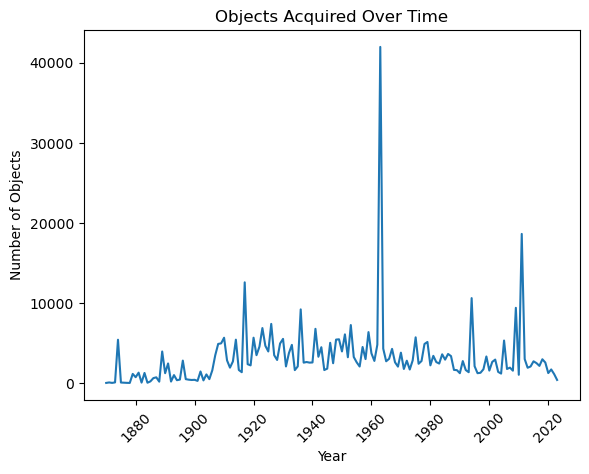

In [187]:
# line plot Accession Year trends

# get the year and count of items aquired in that year, and sort them by year
year_counts = df_met['AccessionYear_dt'].dt.year.value_counts().sort_index()

# Plot the graph based on the values
plt.plot(year_counts.index, year_counts.values)
plt.title('Objects Acquired Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Objects')
plt.xticks(rotation=45)


Text(0, 0.5, 'Object ID')

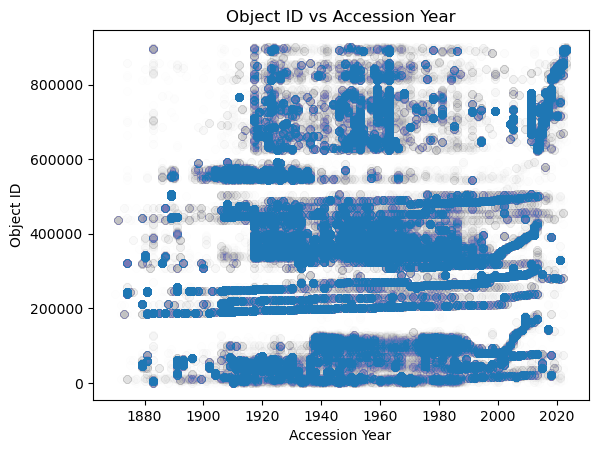

In [201]:
# Scatter plot for same data, Object ID vs AccessionYear 

# fetch year from AccessionYear_dt and choose an alpha of 0.005 to make it a lot transparetn
plt.scatter(df_met['AccessionYear_dt'].dt.year, df_met['Object ID'], alpha=0.005)
plt.title('Object ID vs Accession Year')
plt.xlabel('Accession Year')
plt.ylabel('Object ID')

Text(0, 0.5, 'Frequency')

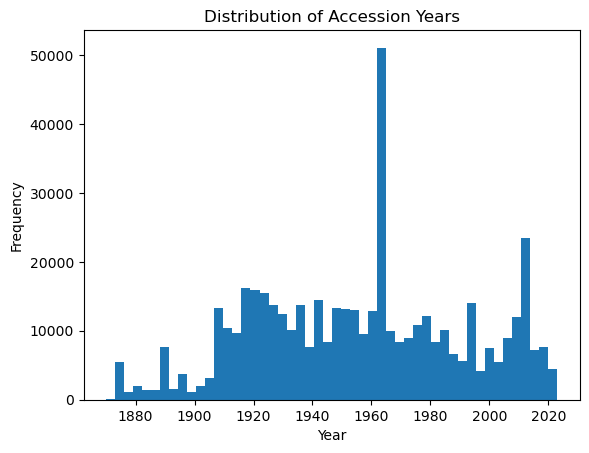

In [221]:
#  A histogram on accession years
plt.hist(df_met['AccessionYear_dt'].dt.year, bins=50)
plt.title('Distribution of Accession Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
